# dataset (CIFAR-10) and dataloader


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Cell 2 — Download the CIFAR-10 Dataset

ToTensor() converts each image into a PyTorch tensor and scales pixel values from 0–255 to 0–1.

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [47:02<00:00, 60.4kB/s]


In [ ]:
print("Training images :", len(train_dataset))
print("Testing images  :", len(test_dataset))

Training images : 50000
Testing images  : 10000


In [ ]:
classes = train_dataset.classes

print("Classes:")
print(classes)

print("\nNumber of classes:", len(classes))

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Number of classes: 10


In [ ]:
image, label = train_dataset[0]

print("Image shape :", image.shape)
print("Label :", label)
print("Class :", classes[label])

Image shape : torch.Size([3, 32, 32])
Label : 6
Class : frog


In [ ]:
plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis("off")
plt.show()

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [ ]:
print("Number of batches:", len(train_loader))

Number of batches: 782


In [ ]:
images, labels = next(iter(train_loader))

In [ ]:
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)

Images shape : torch.Size([64, 3, 32, 32])
Labels shape : torch.Size([64])


In [ ]:
print(labels)

tensor([7, 4, 7, 2, 7, 5, 6, 4, 5, 1, 2, 8, 1, 8, 3, 8, 4, 7, 2, 9, 8, 1, 1, 6,
        6, 0, 6, 4, 6, 8, 5, 4, 1, 1, 3, 3, 7, 7, 6, 8, 5, 8, 0, 9, 2, 2, 6, 9,
        8, 2, 2, 1, 6, 2, 1, 2, 1, 1, 9, 3, 2, 0, 9, 0])


In [ ]:
for i in range(10):
    print(labels[i].item(), "->", classes[labels[i]])

7 -> horse
4 -> deer
7 -> horse
2 -> bird
7 -> horse
5 -> dog
6 -> frog
4 -> deer
5 -> dog
1 -> automobile


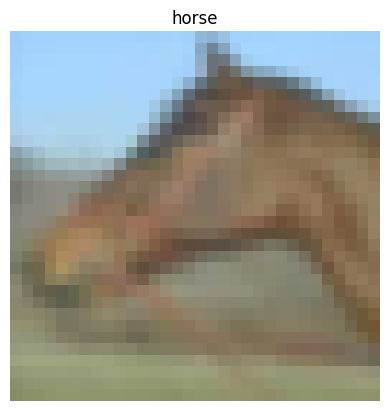

In [ ]:
plt.imshow(images[0].permute(1, 2, 0))
plt.title(classes[labels[0]])
plt.axis("off")
plt.show()

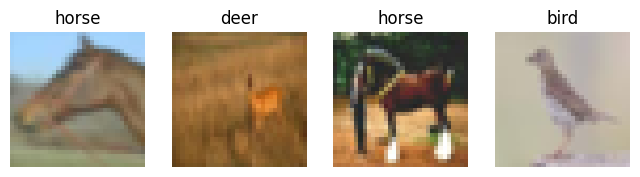

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.show()

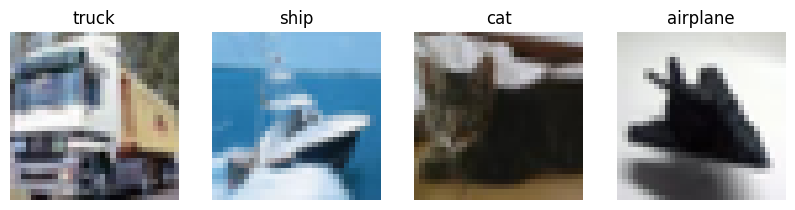

In [ ]:
wanted = ["airplane", "cat", "ship", "truck"]

plt.figure(figsize=(10, 3))

plot_index = 1

for image, label in train_dataset:
    class_name = classes[label]

    if class_name in wanted:
        plt.subplot(1, 4, plot_index)
        plt.imshow(image.permute(1, 2, 0))
        plt.title(class_name)
        plt.axis("off")

        wanted.remove(class_name)
        plot_index += 1

    if len(wanted) == 0:
        break

plt.show()

In [ ]:
print("Training images :", len(train_dataset))
print("Testing images  :", len(test_dataset))
print("Classes         :", classes)
print("Number of classes:", len(classes))
print("Batch shape     :", images.shape)
print("Labels shape    :", labels.shape)

Training images : 50000
Testing images  : 10000
Classes         : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10
Batch shape     : torch.Size([64, 3, 32, 32])
Labels shape    : torch.Size([64])
